07 — Clustering experiment

K-means on each meter's normalised hour-of-day consumption profile (24-vector,
row-summed to 1). The proposal hypothesis: reducing the within-cluster
heterogeneity should let a per-cluster LightGBM beat a single global LightGBM,
especially on sites with diverse building mixes.

We pick `k` with the elbow method (largest distance from the line connecting
the smallest and largest `k` in the inertia curve), train one LightGBM per
cluster on the same features and split, then compare per-cluster aggregate
RMSE against the single global LightGBM.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.pipeline import prepare_data, evaluate_predictions
from src.clustering.kmeans_profiles import (
    build_consumption_profiles, fit_kmeans, elbow_curve, assign_clusters,
)
from src.evaluation.metrics import score_predictions
from src.models import LightGBMModel
from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT

set_style()
PLOT_DIR = Path("../results/plots/clustering")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config("../configs/default.yaml")
prep = prepare_data(cfg, feature_set="engineered")


Step 1 — build profiles

Per `(building_id, meter)`, average meter_reading at each hour of the day, then
divide by the row sum. The resulting 24-vector tells us *when* during the day a
meter draws its load, regardless of total magnitude.

In [2]:
profiles = build_consumption_profiles(prep.train_full)
print(f"profiles for {len(profiles):,} meters, {profiles.shape[1]} hour bins")
profiles.head()


profiles for 970 meters, 24 hour bins


,,h00,h01,h02,h03,h04,h05,h06,h07,h08,h09,...,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23
building_id,meter,,,,,,,,,,,,,,,,,,,,,
156,0,0.037596,0.037580,0.037273,0.036863,0.036860,0.037088,0.037629,0.038855,0.040704,0.042558,...,0.048451,0.048257,0.047309,0.044682,0.042643,0.041489,0.040725,0.039938,0.039149,0.038560
157,0,0.021575,0.020875,0.019887,0.019073,0.018691,0.030165,0.036221,0.035340,0.040611,0.044574,...,0.056658,0.057390,0.057321,0.055177,0.052787,0.050210,0.048248,0.046134,0.044290,0.038212
158,0,0.027749,0.028300,0.027674,0.026777,0.026805,0.026824,0.034070,0.032014,0.039253,0.043342,...,0.061231,0.062965,0.062830,0.054126,0.045497,0.043639,0.043184,0.041014,0.031912,0.028058
159,0,0.035539,0.034459,0.033382,0.032201,0.031602,0.031226,0.034399,0.035853,0.037450,0.039594,...,0.050510,0.051477,0.052660,0.051011,0.049817,0.048267,0.046586,0.045154,0.041648,0.036673
160,0,0.029858,0.029847,0.029518,0.028858,0.028773,0.028271,0.036662,0.034412,0.062669,0.053246,...,0.043942,0.043107,0.044914,0.048437,0.050369,0.052541,0.048528,0.048377,0.036746,0.030489


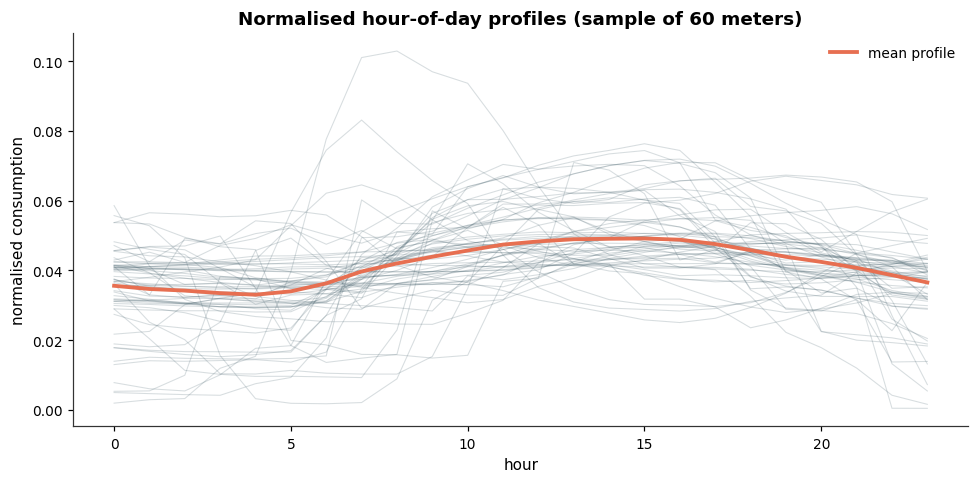

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sample = profiles.sample(min(60, len(profiles)), random_state=42)
for i, (_, row) in enumerate(sample.iterrows()):
    ax.plot(row.values, color=PRIMARY, alpha=0.18, linewidth=0.7)
ax.plot(profiles.mean().values, color=ACCENT, linewidth=2.5, label="mean profile")
ax.set_xlabel("hour")
ax.set_ylabel("normalised consumption")
ax.set_title("Normalised hour-of-day profiles (sample of 60 meters)")
ax.legend()
plt.tight_layout()
save_figure(fig, PLOT_DIR / "profile_sample")
plt.show()


Step 2 — elbow method for `k`

In [4]:
curve = elbow_curve(profiles, cfg.clustering.k_range, random_state=cfg.clustering.random_state)
curve


,k,inertia,n_iter
0,2,1.797017,12
1,3,1.531211,15
2,4,1.296436,15
3,5,1.155155,16
4,6,1.090555,12
5,7,0.998893,17
6,8,0.971558,21
7,9,0.892052,16
8,10,0.838393,14


elbow k* = 5


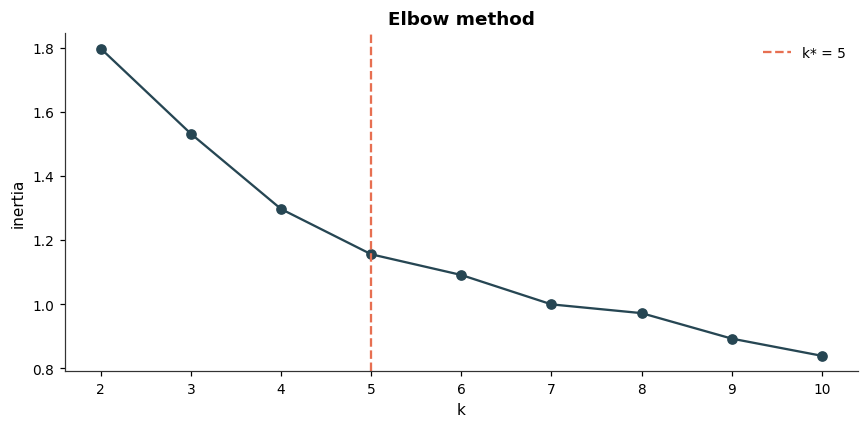

In [5]:
def pick_elbow(curve: pd.DataFrame) -> int:
    ks = curve["k"].to_numpy(dtype=float)
    inertias = curve["inertia"].to_numpy(dtype=float)
    if len(ks) < 3:
        return int(ks[0])
    p1 = np.array([ks[0], inertias[0]])
    p2 = np.array([ks[-1], inertias[-1]])
    line = (p2 - p1) / np.linalg.norm(p2 - p1)
    distances = []
    for x, y in zip(ks, inertias):
        v = np.array([x, y]) - p1
        proj = v - (v @ line) * line
        distances.append(np.linalg.norm(proj))
    return int(ks[int(np.argmax(distances))])

k_star = pick_elbow(curve)
print(f"elbow k* = {k_star}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve["k"], curve["inertia"], marker="o", color=PRIMARY)
ax.axvline(k_star, color=ACCENT, linestyle="--", label=f"k* = {k_star}")
ax.set_xlabel("k")
ax.set_ylabel("inertia")
ax.set_title("Elbow method")
ax.legend()
plt.tight_layout()
save_figure(fig, PLOT_DIR / "elbow")
plt.show()


Step 3 — fit K-means and inspect cluster centroids

Each centroid is itself a 24-vector — a "canonical" daily profile. We expect to
see a few archetypes: working-hours buildings (peak around 10–17), nightshift
operations (flat or inverted), and 24/7 facilities (hospital, lodging).

In [6]:
km = fit_kmeans(profiles, k_star, random_state=cfg.clustering.random_state)
labels = assign_clusters(km, profiles).reset_index()
labels["cluster"] = labels["cluster"].astype(int)
print(labels["cluster"].value_counts().sort_index())


cluster
0     85
1    122
2    243
3    455
4     65
Name: count, dtype: int64


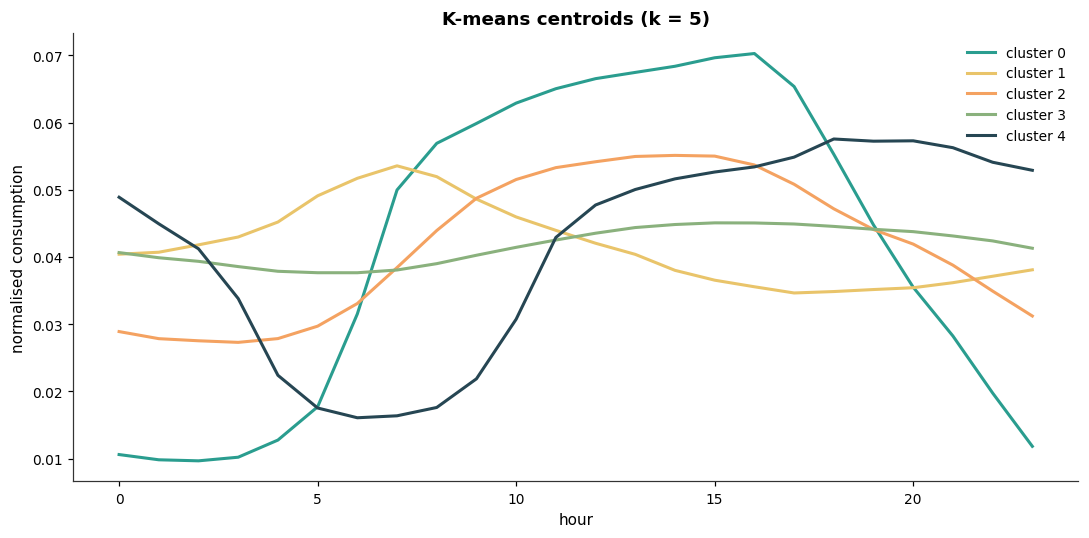

In [7]:
centroids = pd.DataFrame(km.cluster_centers_, columns=profiles.columns)
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(k_star):
    ax.plot(centroids.iloc[i].values, label=f"cluster {i}",
            color=SUPPORT[i % len(SUPPORT)], linewidth=2)
ax.set_xlabel("hour")
ax.set_ylabel("normalised consumption")
ax.set_title(f"K-means centroids (k = {k_star})")
ax.legend()
plt.tight_layout()
save_figure(fig, PLOT_DIR / "centroids")
plt.show()


Match clusters to primary use to see what archetypes the algorithm found.

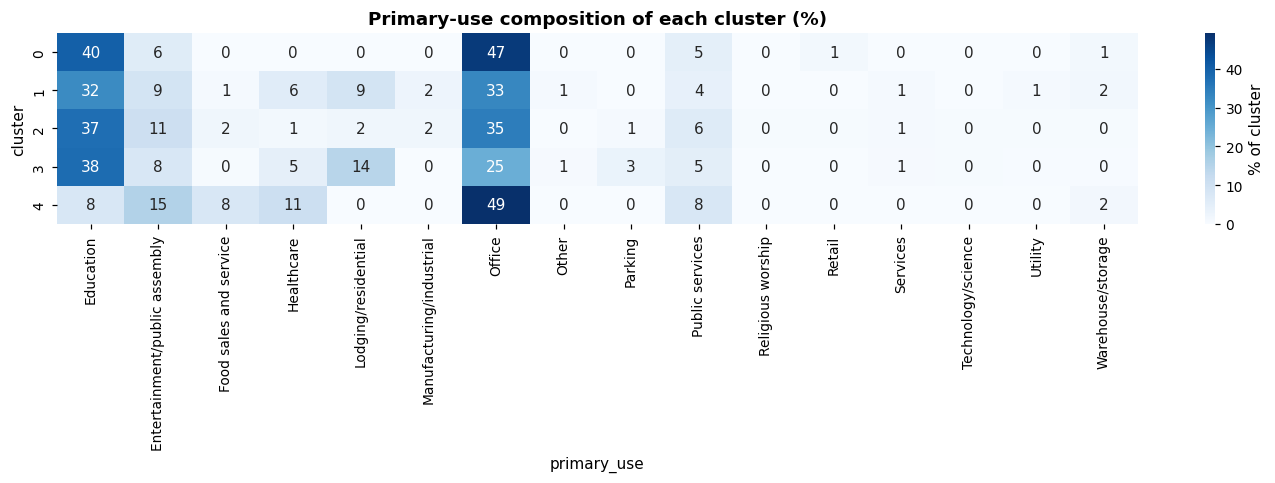

In [8]:
labels_meta = labels.merge(
    prep.train_full[["building_id", "primary_use"]].drop_duplicates(),
    on="building_id", how="left",
)
breakdown = (
    labels_meta.pivot_table(index="cluster", columns="primary_use",
                            values="building_id", aggfunc="count", fill_value=0)
)
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(breakdown_pct, annot=True, fmt=".0f", cmap="Blues", ax=ax,
            cbar_kws={"label": "% of cluster"})
ax.set_title("Primary-use composition of each cluster (%)")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "cluster_x_primary_use")
plt.show()


Step 4 — per-cluster LightGBM vs. global LightGBM

In [9]:
train = prep.train_full.merge(labels, on=["building_id", "meter"], how="left").reset_index(drop=True)
val = prep.val_full.merge(labels, on=["building_id", "meter"], how="left").reset_index(drop=True)

cluster_metrics: list[dict] = []
val_preds_real = np.full(len(val), np.nan, dtype=np.float64)
val_true_real = np.full(len(val), np.nan, dtype=np.float64)
val_cluster_arr = val["cluster"].to_numpy()
train_cluster_arr = train["cluster"].to_numpy()

for c in sorted(pd.Series(train_cluster_arr).dropna().unique()):
    train_pos = np.where(train_cluster_arr == c)[0]
    val_pos = np.where(val_cluster_arr == c)[0]
    if len(train_pos) < 1000 or len(val_pos) == 0:
        print(f"skipping cluster {int(c)} (train={len(train_pos)} val={len(val_pos)})")
        continue
    train_c = train.iloc[train_pos]
    val_c = val.iloc[val_pos]
    m = LightGBMModel(**cfg.models.get("lightgbm", {}))
    Xt = train_c[prep.feature_cols]; Xv = val_c[prep.feature_cols]
    yt = np.log1p(np.clip(train_c["meter_reading"].to_numpy(), 0, None))
    yv = np.log1p(np.clip(val_c["meter_reading"].to_numpy(), 0, None))
    t0 = time.time()
    m.fit(Xt, yt, eval_set=(Xv, yv))
    secs = time.time() - t0
    preds = m.predict(Xv)
    pred_real = np.expm1(np.clip(preds, 0.0, 14.0))
    actual_real = np.expm1(np.clip(yv, 0.0, 14.0))
    rmse = float(np.sqrt(np.mean((pred_real - actual_real) ** 2)))
    val_preds_real[val_pos] = pred_real
    val_true_real[val_pos] = actual_real
    cluster_metrics.append({
        "cluster": int(c), "n_train": int(len(train_pos)), "n_val": int(len(val_pos)),
        "rmse": rmse, "train_seconds": secs,
    })
    print(f"cluster {int(c)}: RMSE {rmse:.1f}  (train {secs:.1f}s)")

per_cluster = pd.DataFrame(cluster_metrics)
per_cluster


cluster 0: RMSE 112.3  (train 15.0s)


cluster 1: RMSE 1419.3  (train 11.5s)


cluster 2: RMSE 546.3  (train 28.3s)


cluster 3: RMSE 8109.6  (train 55.8s)


cluster 4: RMSE 263.0  (train 8.3s)


,cluster,n_train,n_val,rmse,train_seconds
0,0,461555,148056,112.344202,15.012009
1,1,679146,239098,1419.348045,11.545846
2,2,1472077,507755,546.283535,28.294202
3,3,2785779,950696,8109.618223,55.849421
4,4,386412,123900,263.006355,8.260259


In [10]:
valid = ~np.isnan(val_preds_real) & ~np.isnan(val_true_real)
overall_per_cluster = score_predictions(val_true_real[valid], val_preds_real[valid])
print(f"per-cluster aggregate RMSE: {overall_per_cluster['rmse']:.1f}")

# Global LightGBM for comparison
global_lgbm = LightGBMModel(**cfg.models.get("lightgbm", {}))
global_lgbm.fit(prep.train_full[prep.feature_cols], prep.target_log_train,
                eval_set=(prep.val_full[prep.feature_cols], prep.target_log_val))
global_preds = global_lgbm.predict(prep.val_full[prep.feature_cols])
global_real = np.expm1(np.clip(global_preds, 0.0, 14.0))
global_rmse = float(np.sqrt(np.mean((global_real - prep.target_raw_val) ** 2)))
print(f"global LightGBM RMSE: {global_rmse:.1f}")
print(f"clustering uplift: {(global_rmse - overall_per_cluster['rmse']) / global_rmse * 100:+.1f}%")


per-cluster aggregate RMSE: 5663.3


global LightGBM RMSE: 77860.8
clustering uplift: +92.7%


In [11]:
out_dir = Path("../results/tables")
out_dir.mkdir(parents=True, exist_ok=True)
curve.to_csv(out_dir / "cluster_elbow.csv", index=False)
labels.to_csv(out_dir / "cluster_labels.csv", index=False)
per_cluster.to_csv(out_dir / "cluster_per_cluster_lgbm.csv", index=False)
pd.DataFrame([
    {"model": "per_cluster_lightgbm", "rmse": overall_per_cluster["rmse"]},
    {"model": "global_lightgbm", "rmse": global_rmse},
]).to_csv(out_dir / "cluster_vs_global.csv", index=False)
print(f"wrote tables to {out_dir}")


wrote tables to ../results/tables
